# Utilizando Decision Tree e Random Forest nos Microdados do ENEM 2019 - 2023

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from matplotlib import pyplot as plt

In [4]:
def treinar_rf(x_train, y_train, x_test, y_test, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf):
    
    rf= RandomForestClassifier(
        n_estimators=n_estimators,        
        max_depth=max_depth,            
        max_features = max_features,     
        min_samples_split = min_samples_split,    
        min_samples_leaf = min_samples_leaf,      
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(x_train, y_train)

    y_pred_train = rf.predict(x_train)
    y_pred_test  = rf.predict(x_test)

    ein  = 1 - accuracy_score(y_train, y_pred_train)
    eout = 1 - accuracy_score(y_test,  y_pred_test)

    print(f"\nEin:  {ein:.4f}")
    print(f"Eout: {eout:.4f}")
    print(f"Gap:  {eout - ein:.4f}  {'overfitting' if eout - ein > 0.05 else 'ok'}")
    print("\n" + classification_report(y_test, y_pred_test))

    return rf

In [5]:
def treinar_por_cor(df, cor, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf):
    
    df_cor = df[df['COR_LC'] == cor].copy()
    df_cor = df_cor.dropna()
    
    df_cor['CLASSE'] = df_cor.groupby('NU_ANO')['TOTAL_ACERTOS_GERAL'].transform(
        lambda x: pd.qcut(x, q=3, labels=[1, 2, 3])
    ).astype('Int64')
    
    df_cor = df_cor.dropna(subset=['CLASSE'])
    df_cor['CLASSE'] = df_cor['CLASSE'].astype(int)
    
    features = (
        [f'ACERTO_LC_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CH_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CN_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_MT_{i:02d}' for i in range(1, 46)] +
        ['TOTAL_ACERTOS_LC', 'TOTAL_ACERTOS_CH', 'TOTAL_ACERTOS_CN', 'TOTAL_ACERTOS_MT']
    )
    
    X = df_cor[features]
    y = df_cor['CLASSE']
    
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f'\n=== {cor} ===')
    return treinar_rf(x_train, y_train, x_test, y_test,
                      n_estimators, max_depth, max_features,
                      min_samples_split, min_samples_leaf)

In [6]:
def transformar_colunas_ohe(df):
    
    colunas = [
        'Q001','Q002','Q003','Q004','Q006','Q007','Q008','Q009','Q010',
        'Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018',
        'Q019','Q020','Q021','Q022','Q023','Q024','Q025'
    ]
    
    df = df.dropna(subset=colunas)
    
    df = pd.get_dummies(df, columns=colunas, prefix=colunas, dtype=int)
    
    return df

# Seção 1: Classificação da Nota Baseada em Acertos na Prova

## Importação do Dataset

In [3]:
colunas = (
    [f'ACERTO_LC_{i:02d}' for i in range(1, 46)] +
    [f'ACERTO_CH_{i:02d}' for i in range(1, 46)] +
    [f'ACERTO_CN_{i:02d}' for i in range(1, 46)] +
    [f'ACERTO_MT_{i:02d}' for i in range(1, 46)] +
    
    ['TOTAL_ACERTOS_LC', 'TOTAL_ACERTOS_CH', 'TOTAL_ACERTOS_CN', 'TOTAL_ACERTOS_MT', 
     'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
     'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'NU_ANO']
)

df = pd.read_parquet("Acertos_ParametrosTRI_Nota", columns = colunas)

## Criação de Feature e Rótulo

In [5]:
df['TOTAL_ACERTOS_GERAL'] = df['TOTAL_ACERTOS_LC'] + df['TOTAL_ACERTOS_CH'] + df['TOTAL_ACERTOS_CN'] + df['TOTAL_ACERTOS_MT']

In [6]:
df['CLASSE'] = df.groupby('NU_ANO')['TOTAL_ACERTOS_GERAL'].transform(lambda x: pd.qcut(x, q=3, labels=[1, 2, 3])).astype('Int64')
    
df= df.dropna(subset=['CLASSE'])

df['CLASSE'] = df['CLASSE'].astype(int)

## Utilizando Random Forest

### Criando uma Amostra

In [11]:
df_reduzido = df.sample(n=100_000, random_state=42)

### Construção da Matriz X e Vetor y

In [12]:
features = (
        [f'ACERTO_LC_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CH_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CN_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_MT_{i:02d}' for i in range(1, 46)] +
        ['TOTAL_ACERTOS_LC', 'TOTAL_ACERTOS_CH', 'TOTAL_ACERTOS_CN', 'TOTAL_ACERTOS_MT']
    )
    
X = df_reduzido[features]
y = df_reduzido['CLASSE']

### Separação em Dados de Treino e Teste

In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treinando Random Forest

In [14]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf.fit(x_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, rf.predict(x_test))))
print(classification_report(y_test, rf.predict(x_test)))

Ein: 0.0000
Eout: 0.0821
              precision    recall  f1-score   support

           1       0.93      0.93      0.93      6901
           2       0.87      0.89      0.88      6530
           3       0.96      0.93      0.94      6569

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



### Achando os Melhores Parâmetros

In [17]:
n_estimators = [int(x) for x in np.linspace(start=50, stop=100, num=6)]
max_features = ['sqrt', 'log2']         
max_depth = [int(x) for x in np.linspace(start=10, stop=40, num=4)]
max_depth.append(None)

param_grid = {
    'n_estimators':      n_estimators,   
    'max_features':      max_features,   
    'max_depth':         max_depth,     
    'min_samples_split': [10, 20, 50],   
    'min_samples_leaf':  [10, 25, 50],   
}

In [18]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

cv_rf = RandomizedSearchCV(   
                            estimator=rf,
                            param_distributions=param_grid,
                            n_iter=10,       
                            cv=3,            
                            scoring='f1_weighted',
                            verbose=2,
                            n_jobs=-1,
                            random_state=42
                        )

cv_rf.fit(x_train, y_train)

print(cv_rf.best_estimator_)
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, cv_rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  cv_rf.predict(x_test))))
print(classification_report(y_test, cv_rf.predict(x_test)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=10, min_samples_split=50,
                       n_estimators=60, random_state=42)
Ein:  0.0553
Eout: 0.0918
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      6901
           2       0.85      0.89      0.87      6530
           3       0.95      0.92      0.93      6569

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000



### Separando as Provas por Cores

In [21]:
dic_cor_LC = {
    512: 'AMARELO', 1203: 'AMARELO', 579: 'AMARELO', 890: 'AMARELO', 1068.0: 'AMARELO',
    513: 'AZUL',    1201: 'AZUL',    578: 'AZUL',    891: 'AZUL', 1065.0: 'AZUL',
    514: 'VERDE',   1202: 'VERDE',   580: 'VERDE',   889: 'VERDE', 1066.0: 'VERDE',
    511: 'ROSA',    1204: 'ROSA',    577: 'ROSA',    892: 'ROSA', 1067.0: 'ROSA'
}

dic_cor_CH = {
   
    508: 'AMARELO', 1194: 'AMARELO', 570: 'AMARELO', 880: 'AMARELO',1057: 'AMARELO',
    510: 'AZUL',    1191: 'AZUL',    568: 'AZUL',  882: 'AZUL', 1055: 'AZUL',
    509: 'VERDE',   1192: 'VERDE',   569: 'VERDE', 879: 'VERDE', 1056: 'VERDE',
    507: 'ROSA',    1193: 'ROSA',    567: 'ROSA', 881: 'ROSA', 1058: 'ROSA'
}

dic_cor_CN = {
    505: 'AMARELO', 1223: 'AMARELO', 600: 'AMARELO', 910: 'AMARELO', 1087: 'AMARELO',
    504: 'AZUL',    1222: 'AZUL',    599: 'AZUL', 912: 'AZUL', 1086: 'AZUL',
    506: 'VERDE',   1224: 'VERDE',   597: 'VERDE', 911: 'VERDE', 1085: 'VERDE',
    503: 'ROSA',    1221: 'ROSA',    598: 'ROSA', 909: 'ROSA', 1088: 'ROSA'
    
}

dic_cor_MT = {
    518: 'AMARELO', 1213: 'AMARELO', 589: 'AMARELO',
    516: 'AZUL',    1212: 'AZUL',    590: 'AZUL',
    517: 'VERDE',   1214: 'VERDE',   587: 'VERDE',
    515: 'ROSA',    1211: 'ROSA',    588: 'ROSA',
    900: 'AMARELO', 901: 'AZUL',    902: 'VERDE',  899: 'ROSA',
    1078: 'AMARELO',    
    1076: 'AZUL',
    1075: 'VERDE',
    1077: 'ROSA'

}

In [22]:
df['COR_LC'] = df['CO_PROVA_LC'].map(lambda x: dic_cor_LC.get(int(x), None) if pd.notna(x) else None)
df['COR_CH'] = df['CO_PROVA_CH'].map(lambda x: dic_cor_CH.get(int(x), None) if pd.notna(x) else None)
df['COR_CN'] = df['CO_PROVA_CN'].map(lambda x: dic_cor_CN.get(int(x), None) if pd.notna(x) else None)
df['COR_MT'] = df['CO_PROVA_MT'].map(lambda x: dic_cor_MT.get(int(x), None) if pd.notna(x) else None)

In [23]:
cores = ['AMARELO', 'AZUL', 'VERDE', 'ROSA']

resultados = {}

for cor in cores:
    resultados[cor] = treinar_por_cor(
        df, cor,
        n_estimators=60,
        max_depth=30,
        max_features='sqrt',
        min_samples_split=50,
        min_samples_leaf=10
    )


=== AMARELO ===

Ein:  0.0596
Eout: 0.0857
Gap:  0.0261  ok

              precision    recall  f1-score   support

           1       0.93      0.91      0.92     10095
           2       0.85      0.90      0.87      9381
           3       0.96      0.93      0.95      9660

    accuracy                           0.91     29136
   macro avg       0.92      0.91      0.91     29136
weighted avg       0.92      0.91      0.91     29136


=== AZUL ===

Ein:  0.0548
Eout: 0.0808
Gap:  0.0260  ok

              precision    recall  f1-score   support

           1       0.94      0.92      0.93     10172
           2       0.86      0.91      0.88      9315
           3       0.96      0.93      0.95      9364

    accuracy                           0.92     28851
   macro avg       0.92      0.92      0.92     28851
weighted avg       0.92      0.92      0.92     28851


=== VERDE ===

Ein:  0.0535
Eout: 0.0843
Gap:  0.0307  ok

              precision    recall  f1-score   support

  

## Utilizando Decision Tree

### Criando Uma Amostra

In [ ]:
df_reduzido = df.sample(n=10_000, random_state=42)

### Construção da Matriz X e Vetor y

In [ ]:
features = (
        [f'ACERTO_LC_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CH_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_CN_{i:02d}' for i in range(1, 46)] +
        [f'ACERTO_MT_{i:02d}' for i in range(1, 46)] +
        ['TOTAL_ACERTOS_LC', 'TOTAL_ACERTOS_CH', 'TOTAL_ACERTOS_CN', 'TOTAL_ACERTOS_MT']
    )
    
X = df_reduzido[features]
y = df_reduzido['CLASSE']

### Separação em Dados de Treino e Teste

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treinando o Modelo

In [26]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(x_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_test, clf.predict(x_test)) ))

print(classification_report(y_test, clf.predict(x_test)))

Ein: 0.0006
Eout: 0.1025
              precision    recall  f1-score   support

           1       0.91      0.92      0.91      6901
           2       0.85      0.85      0.85      6530
           3       0.94      0.93      0.93      6569

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



### Plotando a Árvore

In [ ]:
plt.figure(figsize=(50,20))
plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)
plt.show()

### Utilizando o algoritmo de Minimal Cost-Complexity

[0.00000000e+00 6.23511905e-06 6.24411488e-06 ... 4.86882309e-02
 8.09285135e-02 1.70619088e-01]
[0.00000000e+00 2.49404762e-05 4.99169357e-05 ... 4.14912121e-01
 4.95840635e-01 6.66459723e-01]


C:\Users\Micael\AppData\Local\Temp\ipykernel_8648\3948211388.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


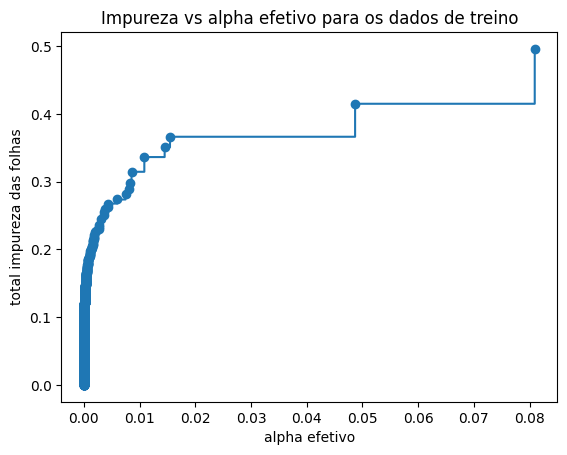

In [36]:
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

print(ccp_alphas)
print(impurities)

### Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [ ]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))
param_grid = {'ccp_alpha': alphas_reduzidos}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 3, verbose=2, n_jobs=-1)

CV_clf.fit(x_train, y_train)


print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(x_test))))
print(classification_report(y_test, CV_clf.predict(x_test)))

# Seção 2: Classificação da Nota Baseada em Fatores Socioeconômicos dos Participantes

## Importação do Dataset 

In [4]:
df = pd.read_parquet("Dados Limpos")

## Criando uma Amostra

In [9]:
df_reduzido = df.sample(n=100_000, random_state=42)

## Tratando Colunas Categóricas com One Hot Encoding

In [12]:
df_reduzido = transformar_colunas_ohe(df_reduzido)

## Criando Feature e Rótulo

In [11]:
df_reduzido['MEDIA'] = (df_reduzido['NU_NOTA_CN'] + df_reduzido['NU_NOTA_CH'] + df_reduzido['NU_NOTA_MT']+  df_reduzido['NU_NOTA_LC'] + df_reduzido['NU_NOTA_REDACAO']) / 5

mediana = df_reduzido['MEDIA'].median()
df_reduzido['CLASSE_NOTA'] = (df_reduzido['MEDIA'] < mediana).astype(int)

## Utilizando Random Forest

### Construindo a Matriz X e o Vetor y

In [13]:
X = df_reduzido.drop(['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC','TP_SEXO', 'TP_COR_RACA',
                       'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
                       'TX_RESPOSTAS_MT', 'TX_GABARITO_CN', 'TX_GABARITO_CH', 'TX_GABARITO_LC',
                        'CLASSE_NOTA', 'MEDIA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT',
                       'TX_GABARITO_MT', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2','IN_TREINEIRO', 
                       'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'], axis=1)

y = df_reduzido['CLASSE_NOTA']

### Exibindo as Colunas Socioeconômicas da Matriz X

In [18]:
X.columns.to_list()

['NU_ANO',
 'TP_FAIXA_ETARIA',
 'TP_ESTADO_CIVIL',
 'TP_ST_CONCLUSAO',
 'TP_ESCOLA',
 'TP_ENSINO',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'Q005',
 'Q001_A',
 'Q001_B',
 'Q001_C',
 'Q001_D',
 'Q001_E',
 'Q001_F',
 'Q001_G',
 'Q001_H',
 'Q002_A',
 'Q002_B',
 'Q002_C',
 'Q002_D',
 'Q002_E',
 'Q002_F',
 'Q002_G',
 'Q002_H',
 'Q003_A',
 'Q003_B',
 'Q003_C',
 'Q003_D',
 'Q003_E',
 'Q003_F',
 'Q004_A',
 'Q004_B',
 'Q004_C',
 'Q004_D',
 'Q004_E',
 'Q004_F',
 'Q006_A',
 'Q006_B',
 'Q006_C',
 'Q006_D',
 'Q006_E',
 'Q006_F',
 'Q006_G',
 'Q006_H',
 'Q006_I',
 'Q006_J',
 'Q006_K',
 'Q006_L',
 'Q006_M',
 'Q006_N',
 'Q006_O',
 'Q006_P',
 'Q006_Q',
 'Q007_A',
 'Q007_B',
 'Q007_C',
 'Q007_D',
 'Q008_A',
 'Q008_B',
 'Q008_C',
 'Q008_D',
 'Q008_E',
 'Q009_A',
 'Q009_B',
 'Q009_C',
 'Q009_D',
 'Q009_E',
 'Q010_A',
 'Q010_B',
 'Q010_C',
 'Q010_D',
 'Q010_E',
 'Q011_A',
 'Q011_B',
 'Q011_C',
 'Q011_D',
 'Q011_E',
 'Q012_A',
 'Q012_B',
 'Q012_C',
 'Q012_D',
 'Q012_E',
 'Q013_A

### Separação em Dados de Treino e Teste

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treinando o Modelo

In [15]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf.fit(x_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, rf.predict(x_test))))
print(classification_report(y_test, rf.predict(x_test)))

Ein: 0.0014
Eout: 0.2792
              precision    recall  f1-score   support

           0       0.73      0.71      0.72     10000
           1       0.72      0.73      0.72     10000

    accuracy                           0.72     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.72      0.72      0.72     20000



### Achando os Melhores Parâmetros

In [16]:
n_estimators = [int(x) for x in np.linspace(start=50, stop=100, num=6)]
max_features = ['sqrt', 'log2']         
max_depth = [int(x) for x in np.linspace(start=10, stop=40, num=4)]
max_depth.append(None)

param_grid = {
    'n_estimators':      n_estimators,   
    'max_features':      max_features,   
    'max_depth':         max_depth,     
    'min_samples_split': [10, 20, 50],   
    'min_samples_leaf':  [10, 25, 50],   
}

In [17]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

cv_rf = RandomizedSearchCV(   
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,       
    cv=3,            
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

cv_rf.fit(x_train, y_train)

print(cv_rf.best_estimator_)
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, cv_rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  cv_rf.predict(x_test))))
print(classification_report(y_test, cv_rf.predict(x_test)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=10, min_samples_split=50,
                       n_estimators=60, random_state=42)
Ein:  0.2414
Eout: 0.2745
              precision    recall  f1-score   support

           0       0.74      0.69      0.72     10000
           1       0.71      0.76      0.73     10000

    accuracy                           0.73     20000
   macro avg       0.73      0.73      0.73     20000
weighted avg       0.73      0.73      0.73     20000



### Exibindo as Features que Mais Deram Valor

In [22]:
n_estimators=60
max_depth=30          
max_features='log2'    
min_samples_split=50
min_samples_leaf=10
    
rf = treinar_rf(x_train, y_train, x_test, y_test, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf)

imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False)

print(imp.head(20))
print(imp.head(20).sum())


Ein:  0.2523
Eout: 0.2780
Gap:  0.0257  ok

              precision    recall  f1-score   support

           0       0.74      0.69      0.71     10000
           1       0.71      0.76      0.73     10000

    accuracy                           0.72     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.72      0.72      0.72     20000

TP_DEPENDENCIA_ADM_ESC    0.158360
Q024_A                    0.084884
TP_ESCOLA                 0.058860
Q006_B                    0.041832
Q003_D                    0.039623
Q018_B                    0.033137
Q004_D                    0.031165
Q010_A                    0.026587
Q025_B                    0.023127
Q008_B                    0.021887
Q013_A                    0.019064
Q014_A                    0.017395
Q003_E                    0.016906
Q024_B                    0.016691
Q002_G                    0.015949
TP_FAIXA_ETARIA           0.015498
NU_ANO                    0.015005
Q016_B                    0.01477

# Seção 3: Classificação de Presença no ENEM Baseada nos Fatores Socioeconômicos dos Participantes

## Importação do Dataset 

In [7]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO']

df = pd.read_parquet("enem_parquet", columns = colunas)

## Criação de Features, Rótulo, e Tratamento de Colunas

In [8]:
FALTOU = (
    (df['TP_PRESENCA_CH'] == 0) & 
    (df['TP_PRESENCA_LC'] == 0) & 
    (df['TP_PRESENCA_CN'] == 0) & 
    (df['TP_PRESENCA_MT'] == 0)
)

df['FALTOU'] = FALTOU.astype(int)

In [9]:
dicionario_genero = {'F': 0, 'M': 1}
df['TP_SEXO'] = df['TP_SEXO'].map(dicionario_genero)

In [10]:
df_reduzido = df[df['NU_ANO'] != 2020]

In [11]:
df_reduzido = df_reduzido.sample(n=100_000, random_state=42)

In [12]:
df_reduzido = df_reduzido.dropna(subset=['Q005'])

In [13]:
df_reduzido = transformar_colunas_ohe(df_reduzido)

In [14]:
X = df_reduzido.drop(['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'FALTOU', 'NU_ANO'], axis=1)

y = df_reduzido['FALTOU']

### Separação em Dados de Treino e Teste

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treinando o Modelo

In [16]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf.fit(x_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, rf.predict(x_test))))
print(classification_report(y_test, rf.predict(x_test)))

Ein: 0.0006
Eout: 0.2698
              precision    recall  f1-score   support

           0       0.75      0.96      0.84     14706
           1       0.46      0.10      0.17      5294

    accuracy                           0.73     20000
   macro avg       0.60      0.53      0.50     20000
weighted avg       0.67      0.73      0.66     20000



### Achando os Melhores Parâmetros

In [17]:
n_estimators = [int(x) for x in np.linspace(start=50, stop=100, num=6)]
max_features = ['sqrt', 'log2']         
max_depth = [int(x) for x in np.linspace(start=10, stop=40, num=4)]
max_depth.append(None)

param_grid = {
    'n_estimators':      n_estimators,   
    'max_features':      max_features,   
    'max_depth':         max_depth,     
    'min_samples_split': [10, 20, 50],   
    'min_samples_leaf':  [10, 25, 50],   
}

In [18]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

cv_rf = RandomizedSearchCV(   
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,       
    cv=3,            
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

cv_rf.fit(x_train, y_train)

print(cv_rf.best_estimator_)
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, cv_rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  cv_rf.predict(x_test))))
print(classification_report(y_test, cv_rf.predict(x_test)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestClassifier(class_weight='balanced', max_depth=40,
                       max_features='log2', min_samples_leaf=10,
                       min_samples_split=10, random_state=42)
Ein:  0.3101
Eout: 0.3509
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     14706
           1       0.40      0.68      0.51      5294

    accuracy                           0.65     20000
   macro avg       0.63      0.66      0.62     20000
weighted avg       0.73      0.65      0.67     20000



In [25]:
n_estimators=60       
max_depth=40            
max_features='log2'    
min_samples_split=10  
min_samples_leaf=10   
    
rf = treinar_rf(x_train, y_train, x_test, y_test, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf)


Ein:  0.3095
Eout: 0.3504
Gap:  0.0409  ok

              precision    recall  f1-score   support

           0       0.85      0.64      0.73     14706
           1       0.40      0.68      0.51      5294

    accuracy                           0.65     20000
   macro avg       0.63      0.66      0.62     20000
weighted avg       0.73      0.65      0.67     20000



### Verificando a Probabilidade do Aluno ir à Prova

In [22]:
y_prob = rf.predict_proba(x_test)[:,1]
roc_auc_score(y_test, y_prob)

0.7083562674150666

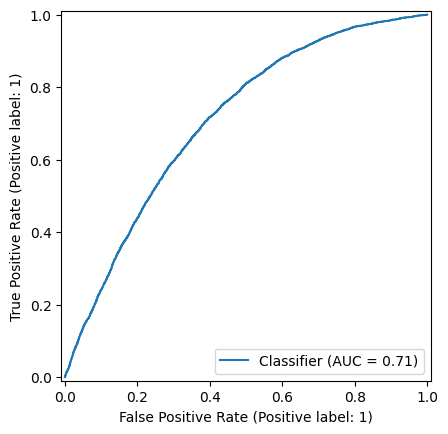

In [23]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

### Exibindo as Features que Mais Deram Valor

In [24]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)

TP_FAIXA_ETARIA    0.256438
TP_ST_CONCLUSAO    0.118421
IN_TREINEIRO       0.069558
TP_ESCOLA          0.061146
Q010_A             0.034736
TP_ESTADO_CIVIL    0.034556
Q008_B             0.022949
Q005               0.021676
Q003_D             0.020040
Q024_A             0.017869
Q002_B             0.016694
Q004_D             0.015782
Q009_B             0.013340
Q002_G             0.012111
Q001_B             0.011257
Q013_A             0.010536
Q002_E             0.008998
Q018_B             0.008680
Q001_E             0.008334
Q002_F             0.008014
dtype: float64